# GLMS in RStan II
# Negative Binomial and Zero-Inflated NB Regression

This article is part of a series:

- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20I%20-%20Poisson%20and%20ZIP%20Regression.ipynb">GLMs in RStan I - Poisson and ZIP Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20II%20-%20Negative%20Binomial%20and%20ZINB%20Regression.ipynb">GLMs in RStan II - Negative Binomial and ZINB Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20III%20-%20Gamma%20Regression.ipynb">GLMs in RStan III - Gamma Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20IV%20-%20GLMs%20in%20RStan%20Summary.ipynb">GLMs in RStan IV - Summary</a>

You may also be interested in <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VII%20-%20Bayesian%20Modeling%20in%20RStan.ipynb">Bayesian Inference VII - Bayesian Modeling in RStan</a>.

# Outline

<ul>
    <li>Generalized Linear Models (GLMs)</li>
    </br>
    <li>Negative Binomial Regression</li>
    </br>
    <li>Negative Binomial Regression Implementation</li>
    </br>
    <li>Zero-Inflated Negative Binomial (ZINB) Regression</li>
        <ul>
            <li>Zero-Inflated Fish Abundance Dataset</li>
        </ul>
    </br>
    <li>Doing it With Priors</li>
        <ul>
            <li>Bootstrapped Intercept and Slope Priors for Total Abundance</li>
            <li>Regular Negative Binomial Regression with Priors</li>
            <li>Bootstrapping ZINB Regression Parameters</li>
            <li>ZINB Regression with Priors</li>
        </ul>

# Generalized Linear Models (GLMs)

A generalized linear model allows the use of custom distributions for the likelihood. We write
$Y \sim \phi(f(\mu), \theta)$, where $\phi$ is an arbitrary distribution, and $\theta$ represents auxiliary parameters, such as $\sigma$ for the normal distribution. $f$ is called the inverse link function, and is the identity function when $\phi$ is normal (so we don't really worry about it), but when using a distribution constrained to positive values, we typically use a log-link function to connect the linear predictor of the mean to the response variable, while ensuring that the constraint is met.

# Negative Binomial Regression

The negative binomial distribution produces positive count outcomes, but unlike the Poisson, can handle variance that is unequal the mean. One common parameterization is in terms of $\alpha$ and $\beta$:

$f(y|\alpha, \beta) = \binom{y + \alpha - 1}{\alpha - 1} \left( \frac{\beta}{\beta + 1} \right)^{\alpha} \left( \frac{1}{\beta+1} \right)^y$

with expected value $E(Y) = \frac{\alpha}{\beta}$ and $Var(Y) = \frac{\alpha}{\beta^2}(\beta + 1)$

This is the parameterization of the first version of the negative binomial model provided in <code>stan</code>. However, we will use a more intuitive version, parameterized in terms of the expected value $\mu$ and a dispersion parameter $\phi$.

$f(y|\mu,\phi) = \binom{y + \phi - 1}{y} \left( \frac{\mu}{\mu + \phi} \right) \left( \frac{\phi}{\mu + \phi} \right)^{\phi}$

with expected value $E(Y) = \mu$ and $Var(Y) = \mu + \frac{\mu^2}{\phi}$.

The Poisson has variance $\mu$, so $\frac{\mu^2}{\phi}$ is the additional variance of the negative binomial above that of the Poisson with mean $\mu$.

The $\mu$ parameter is what we will determine via regression, setting:

$y \sim \text{NB}(\alpha + \beta x, \phi)$

In [ ]:
# install.packages("BiocManager")
# library("BiocManager")

# BiocManager::install("rstan")
# BiocManager::install("GGally")
# BiocManager::install("boot")
# BiocManager::install("COUNT")

library(rstan)
library(GGally) # for pair plots
library(boot) # for bootstrapping
library(MASS) # for glm modeling
library(COUNT) # for fishing dataset

We'll simulate the data using a <code>stan</code> model with only a <code>generated quantities{}</code> block. Note that in order to do this, we pass in the argument <code>algorithm = "Fixed_param"</code> when compiling the model.

In [17]:
stan_code <- "

generated quantities {
  int x_pred[100];
  int y_pred[100];

  for (n in 1:100) {
    x_pred[n] = poisson_rng(6);
    real alpha = normal_rng(0.75, 0.05);
    real beta = normal_rng(0.4, 0.05);
    y_pred[n] = neg_binomial_2_rng(exp(alpha + beta * x_pred[n]), 30);
  }
}
"

In [18]:
model_fit <- stan(model_code = stan_code, iter = 2, chains = 1, refresh = 0, algorithm = "Fixed_param")

Then, extract the samples,

In [19]:
posterior_samples <- extract(model_fit)
x_samples <- as.vector(posterior_samples$x_pred)
y_samples <- as.vector(posterior_samples$y_pred)

And visualize the data.

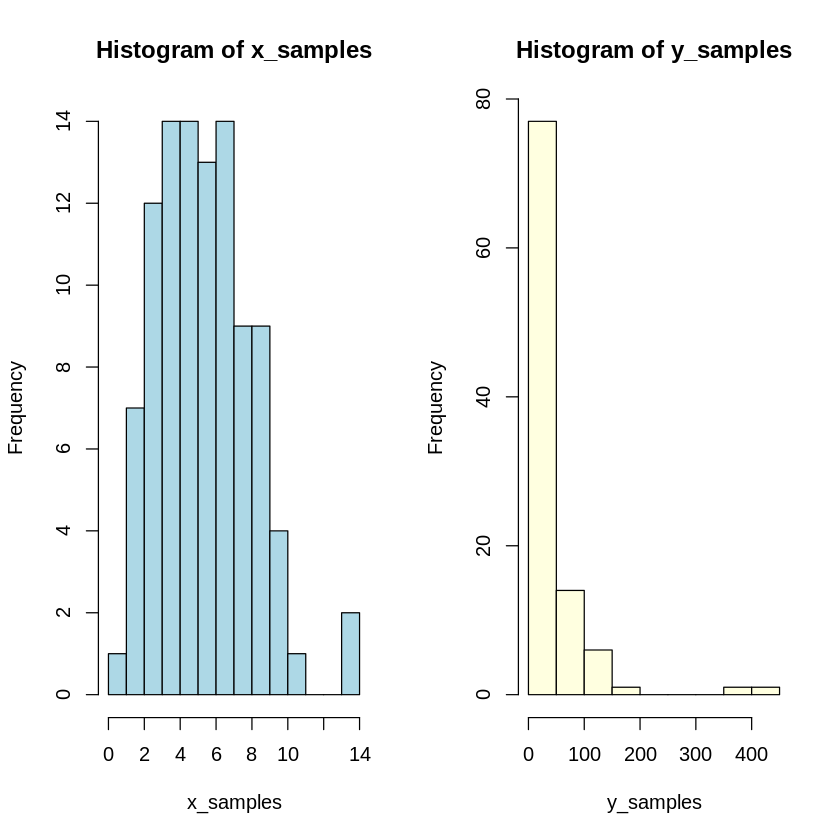

In [21]:
par(mfrow=c(1,2))
hist(x_samples, breaks=10, col="lightblue")
hist(y_samples, breaks=10, col="lightyellow")

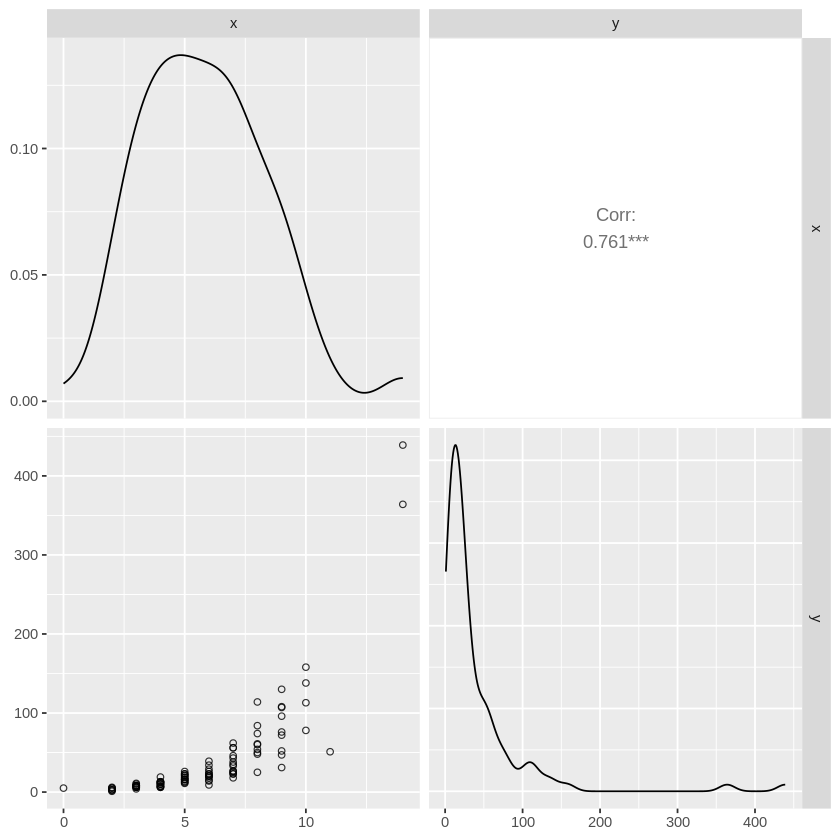

In [22]:
df <- data.frame(x = x_samples, y = y_samples)
ggpairs(df, lower = list(continuous = wrap("points", alpha = 0.8, shape = 1)),)

The first model will have no priors (thereby defaulting to flat ones), and looks as follows.

In [25]:
stan_code <- "

data {
  int<lower=0> N;
  int<lower=0> x[N];
  int<lower=0> y[N];
}

parameters {
  real<lower=0> lambda;
  real alpha, beta;
  real<lower=0> phi;
}

model {
  x ~ poisson(lambda);

  for (n in 1:N){
    y ~ neg_binomial_2(exp(alpha + beta * x[n]), phi);
  }
}

generated quantities {
  int x_pred[N];
  int y_pred[N];

  for (n in 1:N) {
    x_pred[n] = poisson_rng(lambda);
    y_pred[n] = neg_binomial_2_rng(exp(alpha + beta * x_pred[n]), phi);
  }
}
"

We run the model,

In [ ]:
x <- x_samples
y <- y_samples
N <- length(x)
data_list <- list(N = N, x = x, y = y)

model_fit <- stan(model_code = stan_code, data = data_list, warmup=2000,
                 iter = 2200, chains = 3, refresh = 0, cores = 8)

Some diagnostics,

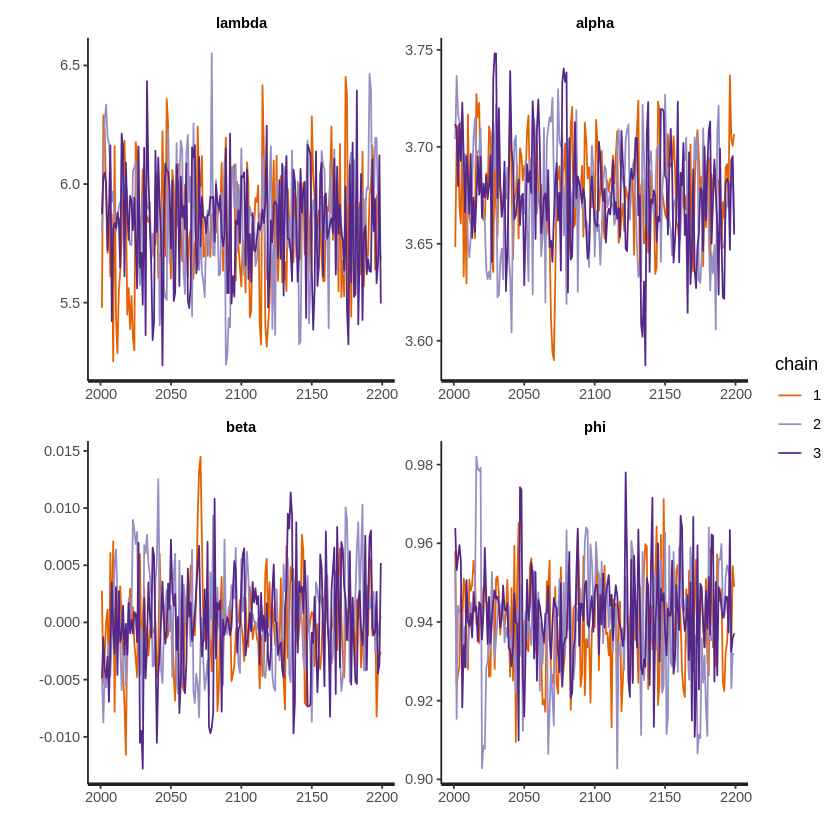

In [27]:
traceplot(model_fit, pars = c('lambda', 'alpha', 'beta', 'phi'))

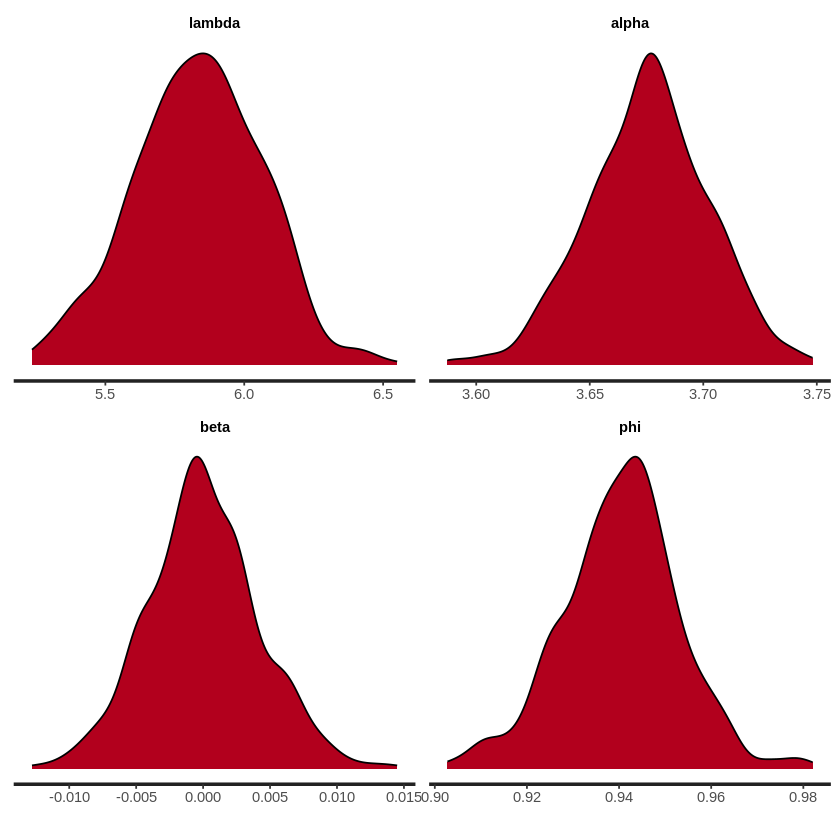

In [28]:
stan_dens(model_fit, pars = c('lambda', 'alpha', 'beta', 'phi'))

And then extract the samples,

In [29]:
posterior_samples <- extract(model_fit)

And visualize the results.

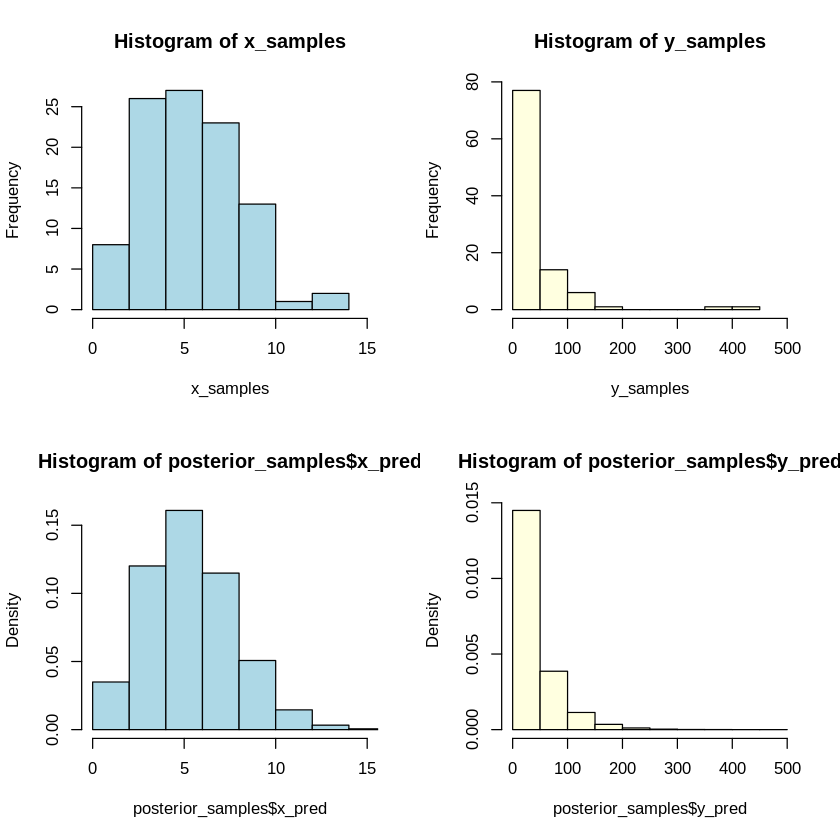

In [34]:
par(mfrow=c(2,2))
hist(x_samples, breaks=8, col="lightblue", xlim = c(0,15))
hist(y_samples, breaks=10, col="lightyellow", xlim = c(0,500))
hist(posterior_samples$x_pred, breaks=10, col="lightblue", probability = TRUE, xlim = c(0,15))
hist(posterior_samples$y_pred, breaks=10, col="lightyellow", probability = TRUE, xlim = c(0,500))

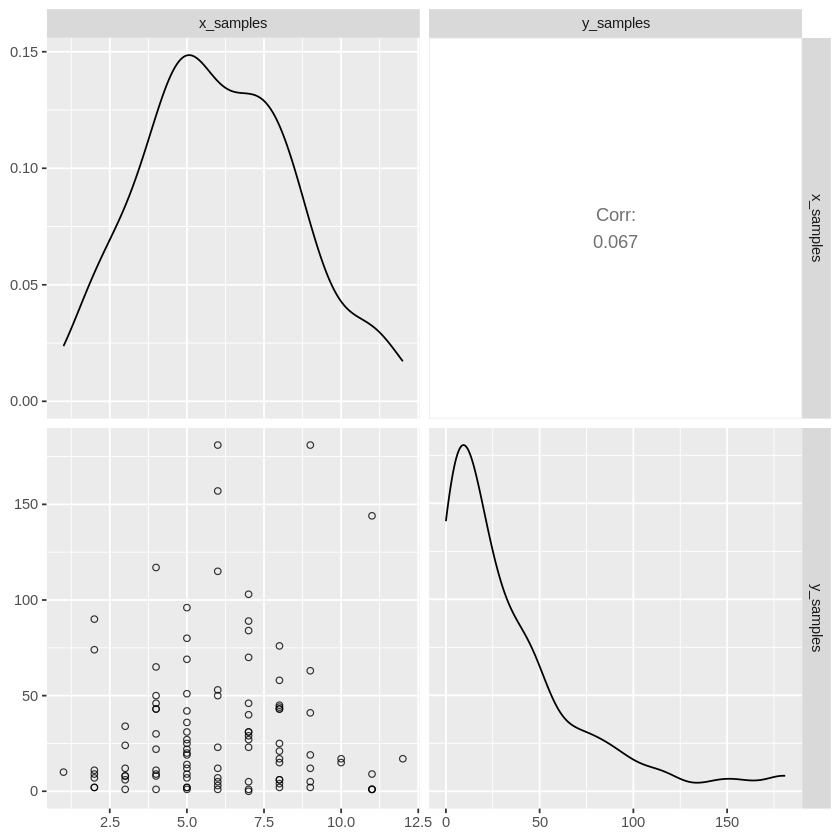

In [35]:
pred_df <- data.frame(x_samples = as.vector(posterior_samples$x_pred),
                      y_samples = as.vector(posterior_samples$y_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 100), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.8, shape = 1)),)

You can see that there is more variation than in the original data. We'll try setting priors that we know closely reflect the true parameters.

In [62]:
stan_code <- "

data {
  int<lower=0> N;
  int<lower=0> x[N];
  int<lower=0> y[N];
}

parameters {
  real alpha, beta;
  real<lower=0> phi;
  real lambda;
}

model {
  lambda ~ normal(6, 0.1);
  x ~ poisson(lambda);
  alpha ~ normal(0.75, 0.1);
  beta ~ normal(0.4, 0.1);
  phi ~ normal(30, 1);

  for (n in 1:N){
    y ~ neg_binomial_2(exp(alpha + beta * x[n]), phi);
  }
}

generated quantities {
  int x_pred[N];
  int y_pred[N];

  for (n in 1:N) {
    x_pred[n] = poisson_rng(lambda);
    y_pred[n] = neg_binomial_2_rng(exp(alpha + beta * x_pred[n]), phi);
  }
}
"

In [ ]:
x <- x_samples
y <- y_samples
N <- length(x)
data_list <- list(N = N, x = x, y = y)

model_fit <- stan(model_code = stan_code, data = data_list, warmup=2000,
                 iter = 2200, chains = 3, refresh = 0, cores = 8)

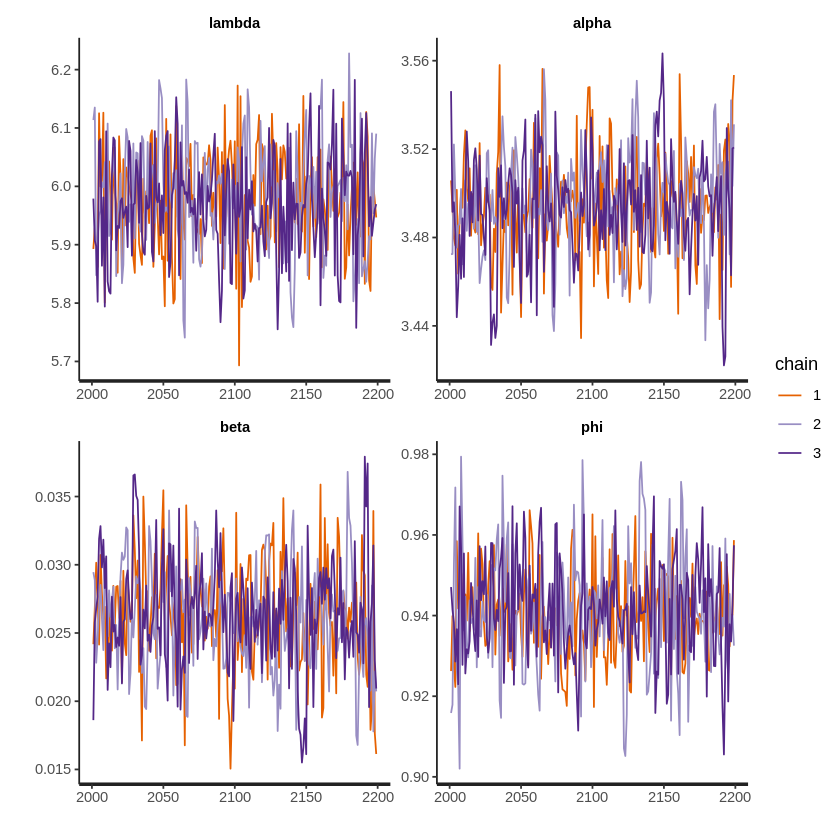

In [66]:
traceplot(model_fit, pars = c('lambda', 'alpha', 'beta', 'phi'))

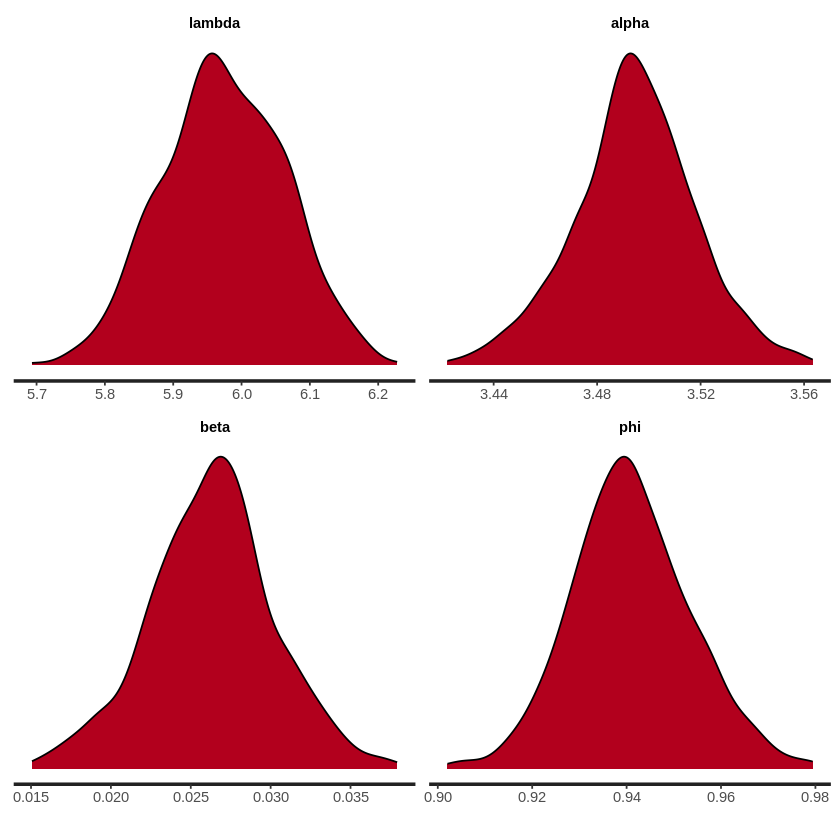

In [67]:
stan_dens(model_fit, pars = c('lambda', 'alpha', 'beta', 'phi'))

In [64]:
posterior_samples <- extract(model_fit)

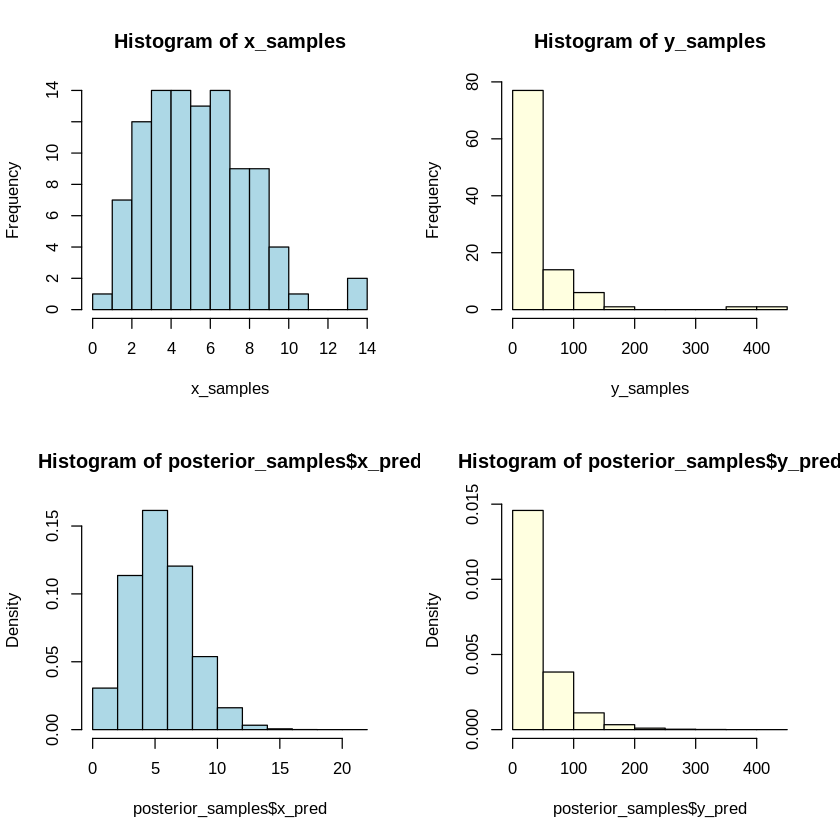

In [65]:
par(mfrow=c(2,2))
hist(x_samples, breaks=10, col="lightblue")
hist(y_samples, breaks=10, col="lightyellow")
hist(posterior_samples$x_pred, breaks=10, col="lightblue", probability = TRUE)
hist(posterior_samples$y_pred, breaks=10, col="lightyellow", probability = TRUE)

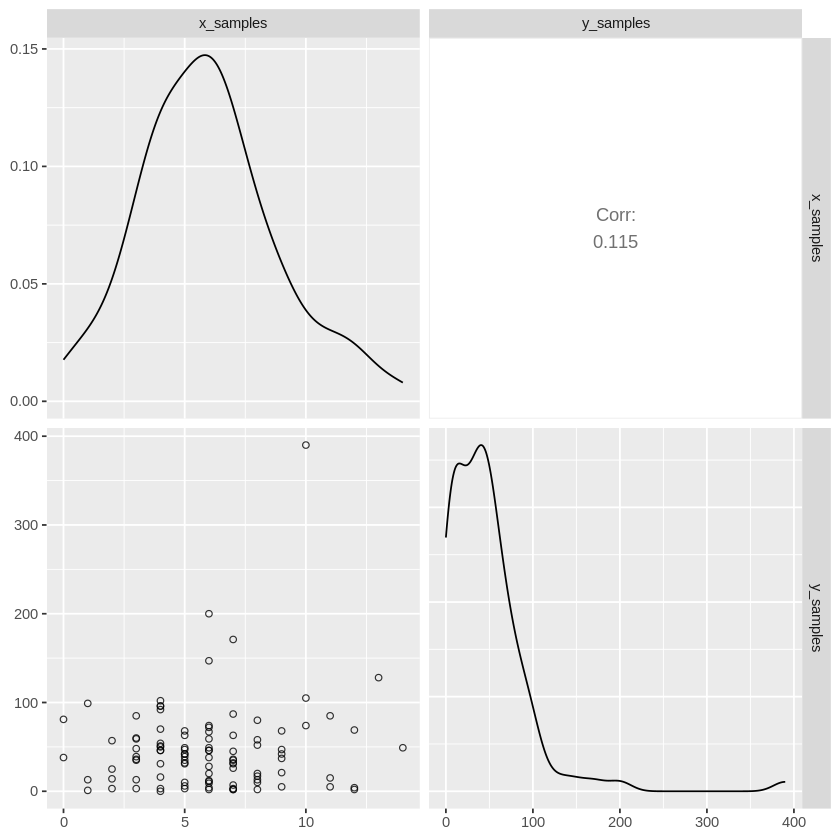

In [68]:
pred_df <- data.frame(x_samples = as.vector(posterior_samples$x_pred),
                      y_samples = as.vector(posterior_samples$y_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 100), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.8, shape = 1)),)

We can see that the model still has difficulty recovering the true parameters. It's true that we're working with a relatively small sample size, and that the negative binomial can be quite sensitive to small changes in parameters. A larger dataset or longer sampling warm-up period may help. Next, we'll try parameters with the same means as priors, but with standard deviations that are an order of magnitude smaller.

In [86]:
stan_code <- "

data {
  int<lower=0> N;
  int<lower=0> x[N];
  int<lower=0> y[N];
}

parameters {
  real alpha, beta;
  real<lower=0> phi;
  real lambda;
}

model {
  lambda ~ normal(6, 0.01);
  x ~ poisson(lambda);
  alpha ~ normal(0.75, 0.01);
  beta ~ normal(0.4, 0.01);
  phi ~ normal(30, 0.1);

  for (n in 1:N){
    y ~ neg_binomial_2(exp(alpha + beta * x[n]), phi);
  }
}

generated quantities {
  int x_pred[N];
  int y_pred[N];

  for (n in 1:N) {
    x_pred[n] = poisson_rng(lambda);
    y_pred[n] = neg_binomial_2_rng(exp(alpha + beta * x_pred[n]), phi);
  }
}
"

In [106]:
x <- x_samples
y <- y_samples
N <- length(x)
data_list <- list(N = N, x = x, y = y)

model_fit <- stan(model_code = stan_code, data = data_list, warmup=2000,
                 iter = 2200, chains = 3, refresh = 0, cores = 8)

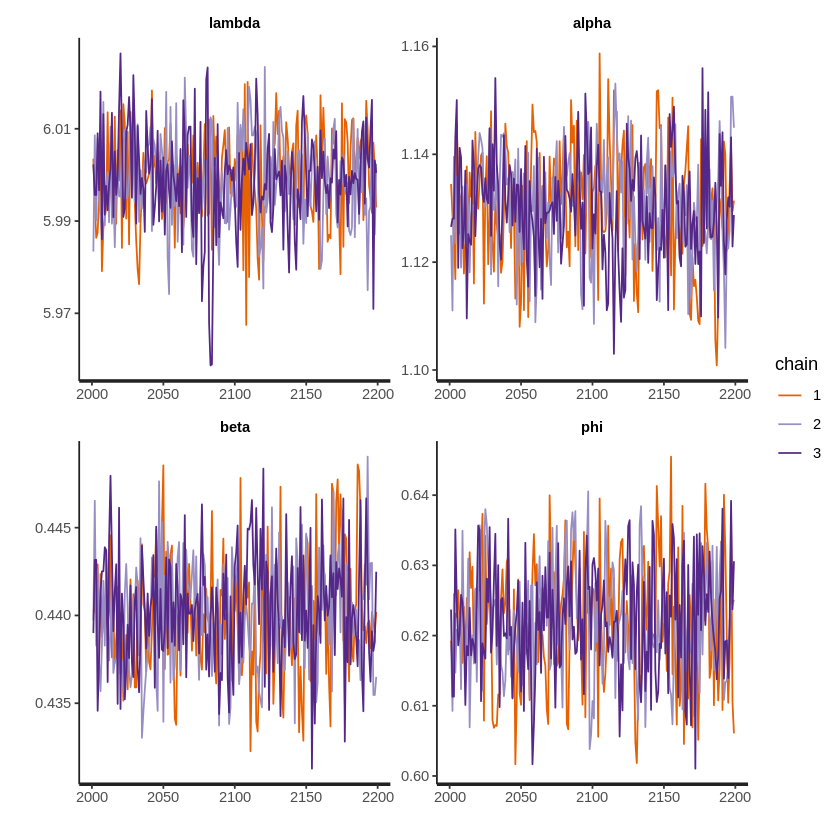

In [107]:
traceplot(model_fit, pars = c('lambda', 'alpha', 'beta', 'phi'))

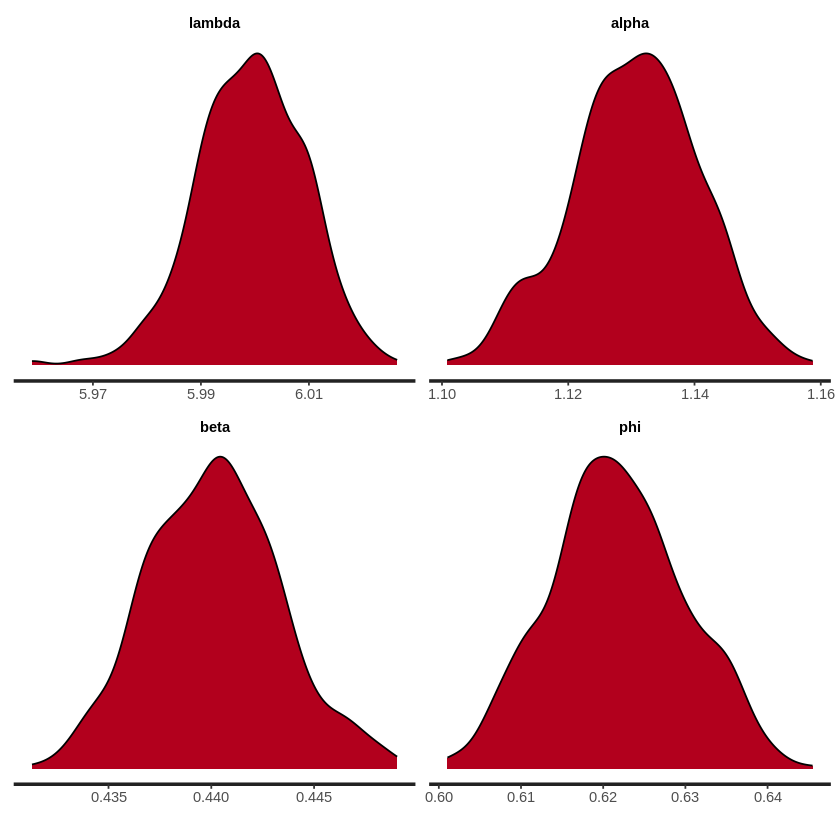

In [108]:
stan_dens(model_fit, pars = c('lambda', 'alpha', 'beta', 'phi'))

In [109]:
posterior_samples <- extract(model_fit)

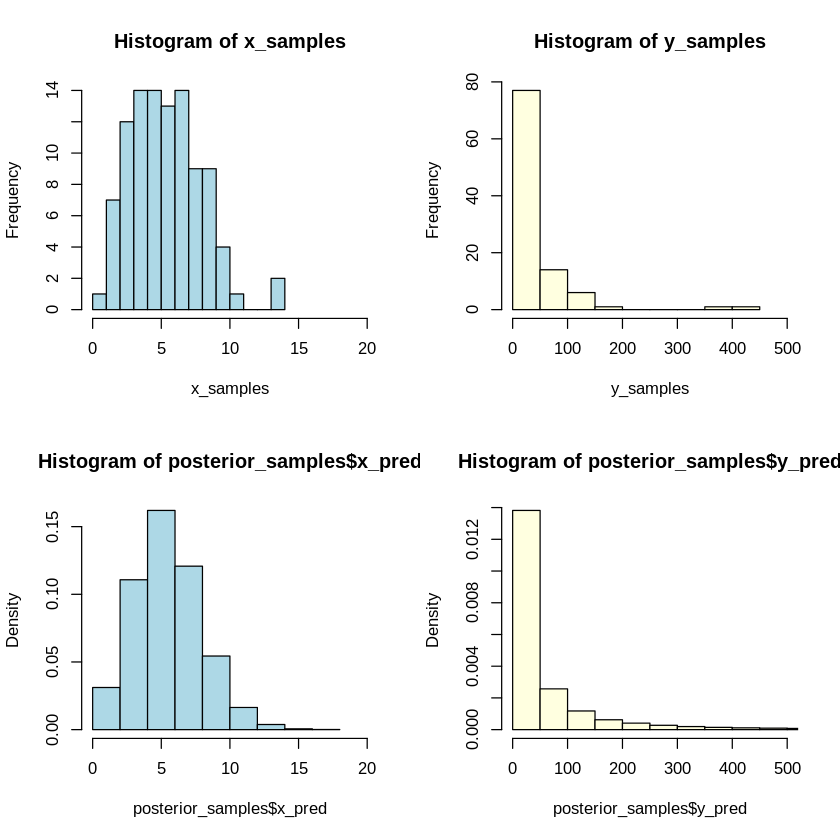

In [110]:
par(mfrow=c(2,2))
hist(x_samples, breaks=10, col="lightblue", xlim = c(0,20))
hist(y_samples, breaks=10, col="lightyellow", xlim = c(0,500))
hist(posterior_samples$x_pred, breaks=12, col="lightblue", probability = TRUE, xlim = c(0,20))
hist(posterior_samples$y_pred, breaks=500, col="lightyellow", probability = TRUE, xlim = c(0,500))

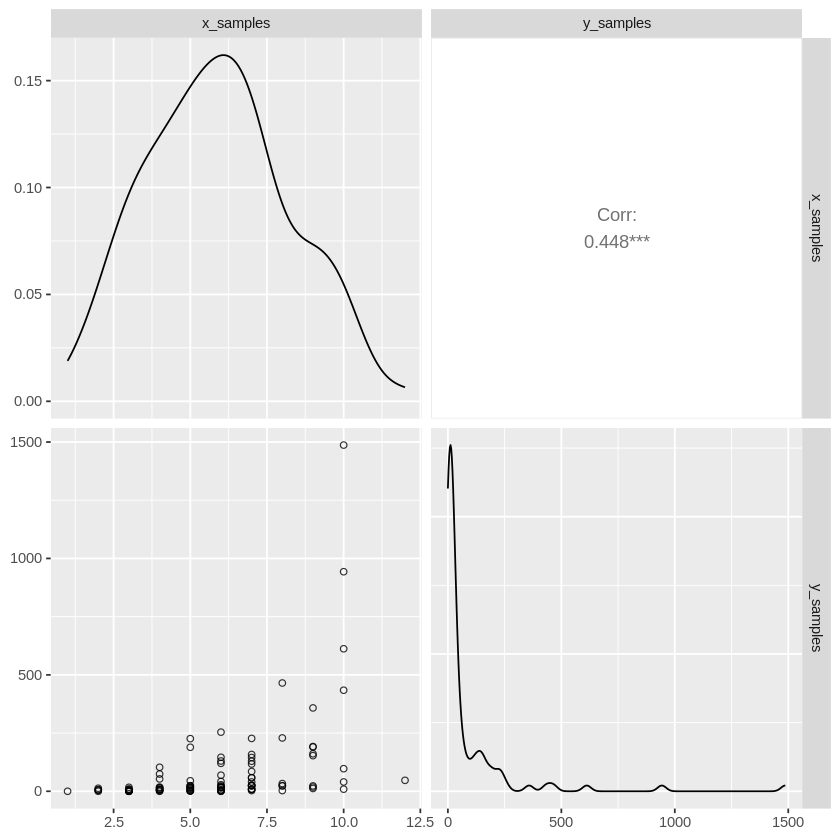

In [111]:
pred_df <- data.frame(x_samples = as.vector(posterior_samples$x_pred),
                      y_samples = as.vector(posterior_samples$y_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 100), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.8, shape = 1)),)

The results look marginally closer to the original data.

# Zero-Inflated Negative Binomial (ZINB) Regression

As with Poisson regression, we can adjust the PMF of our dependent variable to select zero with probability $\pi$, or draw from the negative binomial distribution with probability $1-\pi$. Zero-inflated negative binomial regression takes the form:

- $P(X=k)  =
\begin{cases}
  0, ~~~~~~~~~~~~~~~~\text{with probability } \pi  \\
  \text{NB}(\lambda_i), ~~~~~~\text{with probability } 1-\pi \\
\end{cases}$

The mean and variance are:

- $E(Y) = (1 - \pi) \cdot \mu$
- $Var(Y) = (1 - \pi) \cdot \mu \cdot \left( 1 + \frac{\mu}{\phi} \right) + \pi(1 - \pi) \cdot \mu^2$

Below, we repeat the above and simply substitute the <code>neg_binomial_2</code> distribution for the <code>poisson</code>. This involves providing the additional 'dispersion' parameter, <code>phi_caught</code>, and providing it with a prior distribution.

## Zero-Inflated Fish Abundance Dataset

We'll import a dataset from the <code>COUNT</code> package about fish abundance counts, and regress the total abundance upon the area swept, but inflate the data with 100 records that show 0 for total abundance.

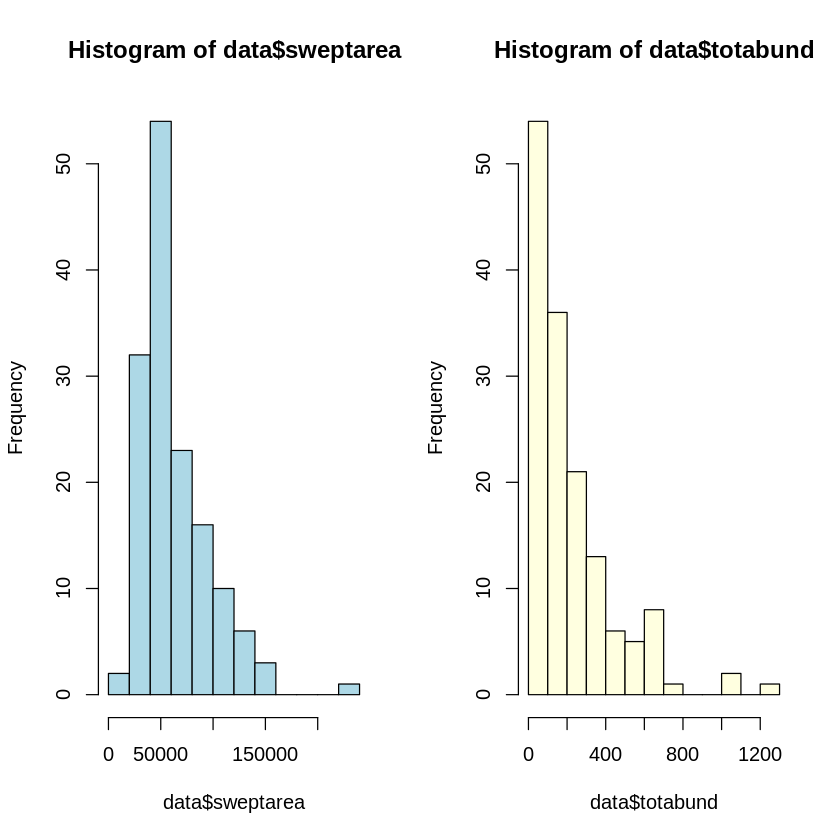

In [112]:
data(fishing)
data <- fishing[, c('sweptarea',  'totabund')]

par(mfrow=c(1,2))
hist(data$sweptarea, col="lightblue")
hist(data$totabund, col="lightyellow")

We add the zeros:

In [113]:
new_x_vals <- abs(rnorm(integer(100), mean = 40000, sd = 20000))
new_y_vals <- seq(0,0,length.out=100)
df <- data.frame(sweptarea = new_x_vals, totabund = new_y_vals)
zero_inf_data <- rbind(data, df)

And then visualize the data.

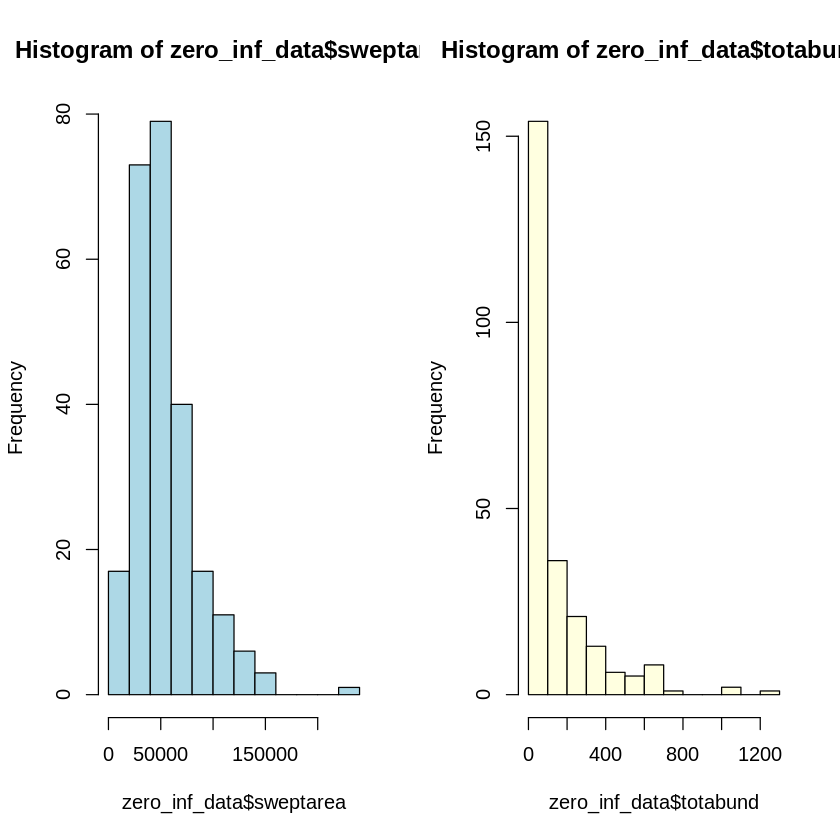

In [114]:
par(mfrow=c(1,2))
hist(zero_inf_data$sweptarea, col="lightblue")
hist(zero_inf_data$totabund, col="lightyellow")

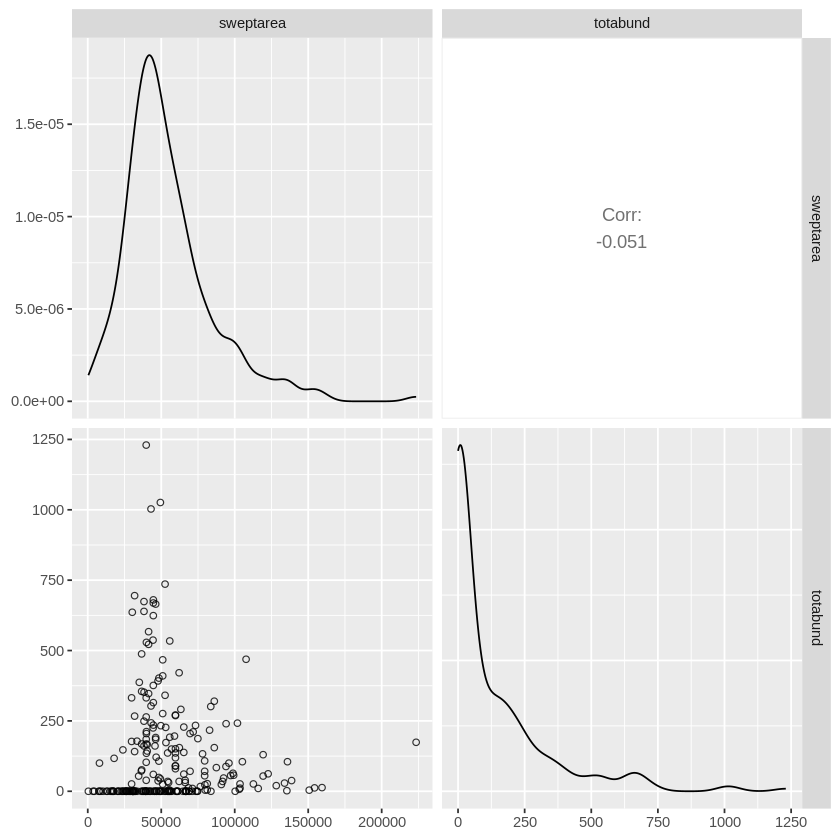

In [115]:
ggpairs(zero_inf_data, lower = list(continuous = wrap("points", alpha = 0.8, shape = 1)))

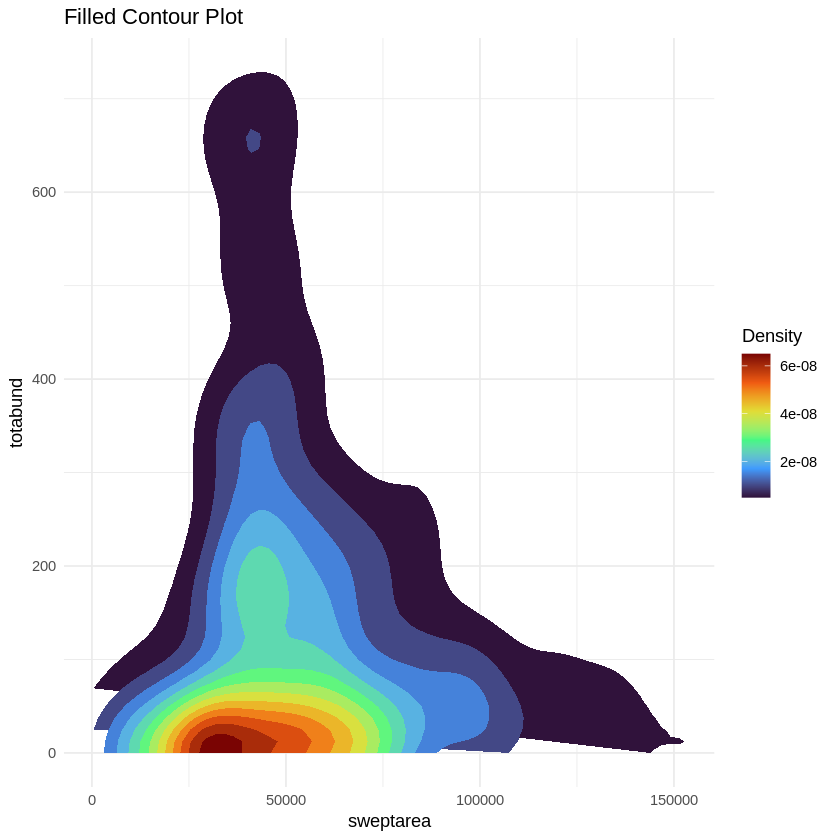

In [116]:
ggplot(zero_inf_data, aes(x = sweptarea, y = totabund)) +
  stat_density_2d(aes(fill = after_stat(level)), geom = "polygon") +
  scale_fill_viridis_c(option = "turbo") +
  theme_minimal() +
  labs(title = "Filled Contour Plot",
       x = "sweptarea", y = "totabund", fill = "Density")

To recap something covered in the previous article on zero-inflated Poisson regression, the model code that will follow now includes in the following elements.

The <code>data{}</code> and <code>parameters{}</code> blocks of our <code>stan</code> code are the same except for the addition of a new parameter <code>pi</code>, bounded between 0 and 1.

- <code>target</code> is a built-in variable which <code>stan</code> uses to track and manage the log-probabilities while sampling. We wouldn't need to know about it unless using a custom-distribution such as our zero-inflation Poisson, as it gets initialized and handled automatically. All our inference method needs to know while sampling is an assessment of the log-probabilities of the samples, so the optimization of parameters is handled simply by us ensuring this information is provided.

- <code>log_mix</code> is a function used to compute the logarithm of a weighted mixture of the densities. You can see 3 components are embedded as arguments:

  - <code>pi</code> is the mixing proportion that determines the probability of drawing a zero from the zero-inflated component.

  - The value of the second argument, 0, represents the log-probability of generating zero from the zero-inflated component. $log(1)=0$, and the probability of a zero from the zero-generating component is 1, so we pass a 0.

  - <code>neg_binom_2_lpmf(0|alpha + beta * x[n], phi)</code> represents the log-probability of drawing a zero from the negative binomial component.

  So within our <code>if</code> statement, if the $n^{th}$ instance of <code>y</code> equals 0, the log-probability of the result is either 0 or the log-probability of a zero from our fitted Poisson, depending on the value of the mixing parameter <code>pi</code>. If <code>y[n]</code> is not equal to zero, we multiply $(1-\pi)$ by the negative binomial likelihood, and since taking the log-probability, we add instead of multiply. <code>log1m</code> is just a numerically stable version of 1 minus the value of the parameter in brackets.

In [155]:
stan_code <- "

data {
  int<lower=0> N;
  vector[N] x;
  int<lower=0> y[N];
}

parameters {
  real<lower=0> x_shape, x_rate;
  real alpha, beta;
  real<lower=0, upper=1>pi;
  real<lower=0> phi;
}

model {
  x ~ gamma(x_shape, x_rate);

  for (n in 1:N) {
    if (y[n] == 0) {
      target += log_mix(pi,
                        0,                                                      // Log prob of y=0 in zero-inflated part
                        neg_binomial_2_lpmf(0 | alpha + beta * x[n], phi));     // Log-prob of y=0 in NB part
    } else {

      target += log1m(pi) + neg_binomial_2_lpmf(y[n] | alpha + beta * x[n], phi);
    }
  }

}

generated quantities {
  vector[N] x_pred;
  int y_pred[N];

  for (n in 1:N) {
    x_pred[n] = gamma_rng(x_shape, x_rate);

    if (bernoulli_rng(pi) == 1) {
      y_pred[n] = 0;
    } else {
      y_pred[n] = neg_binomial_2_rng(fabs(alpha + beta * x_pred[n]), phi);
    }
  }
}
"

We run the model,

In [ ]:
x <- zero_inf_data$sweptarea
y <- zero_inf_data$totabund
N <- length(x)
data_list <- list(N = N, x = x, y = y)

model_fit <- stan(model_code = stan_code, data = data_list, warmup=4000,
                 iter = 4200, chains = 2, refresh = 0, cores = 8)

Diagnostics,

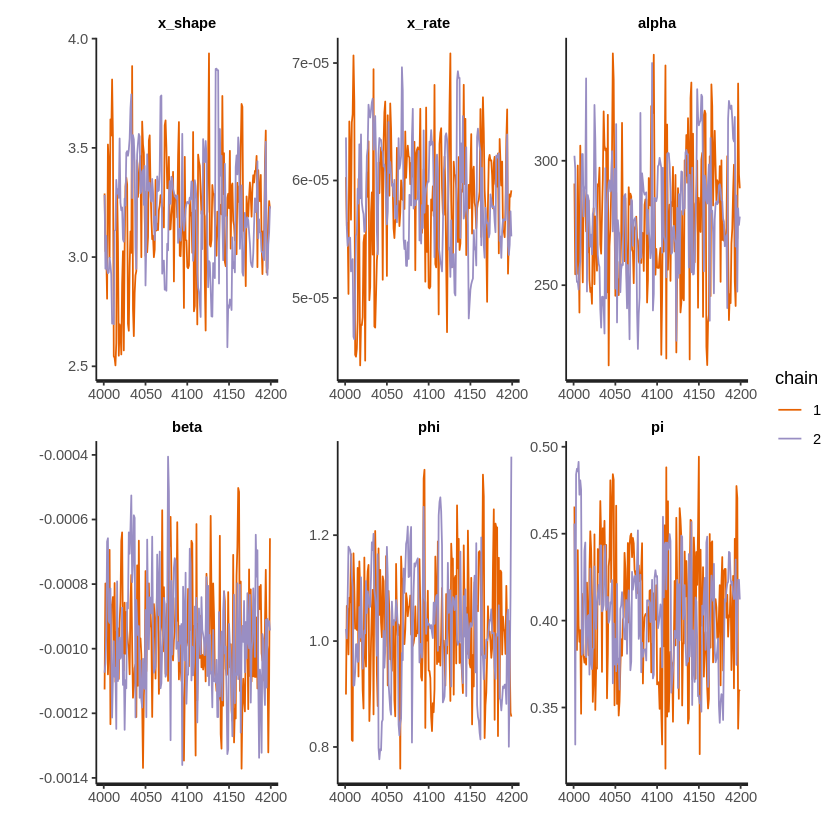

In [157]:
traceplot(model_fit, pars = c('x_shape', 'x_rate', 'alpha', 'beta', 'phi', 'pi'))

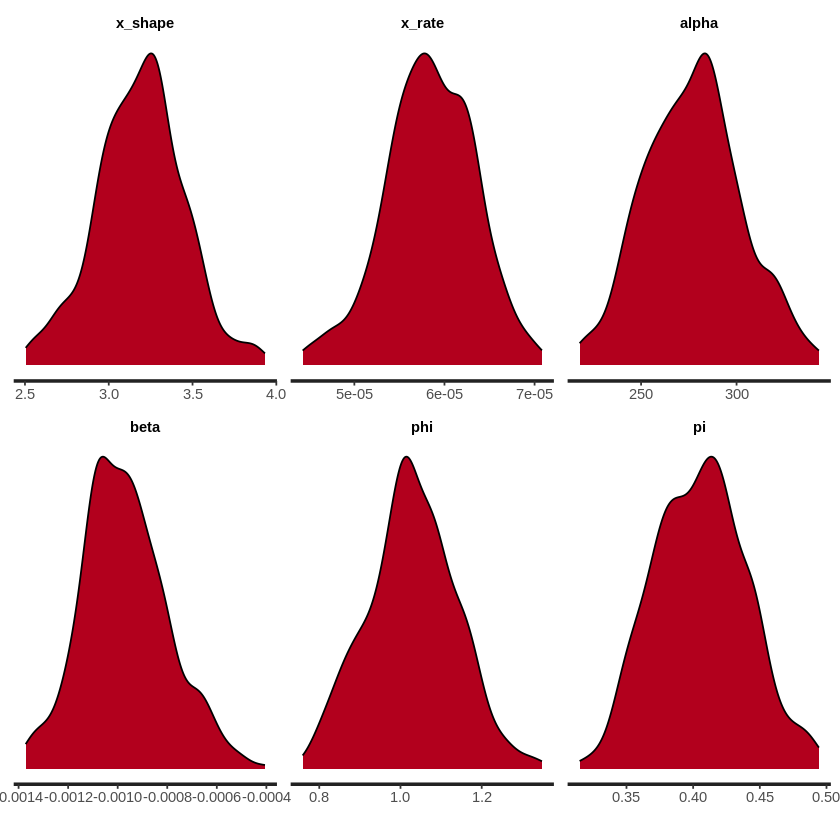

In [158]:
stan_dens(model_fit, pars = c('x_shape', 'x_rate', 'alpha', 'beta', 'phi', 'pi'))

And then extract and visualize the samples.

In [159]:
posterior_samples <- extract(model_fit)

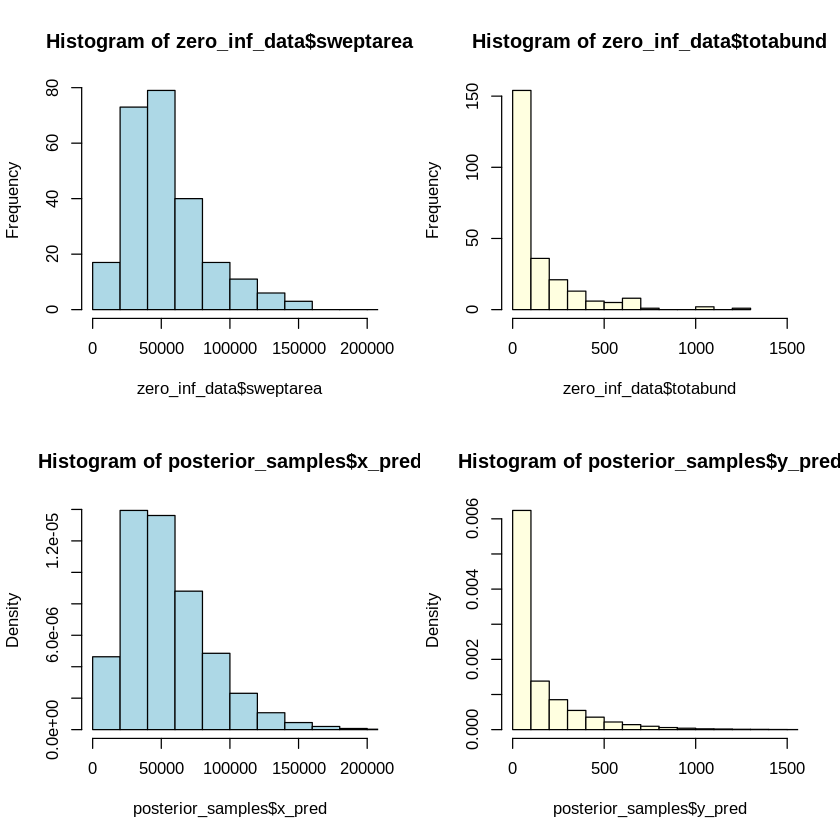

In [161]:
par(mfrow=c(2,2))
hist(zero_inf_data$sweptarea, breaks=10, col="lightblue", xlim = c(0,200000))
hist(zero_inf_data$totabund, breaks=10, col="lightyellow", xlim = c(0,1500))
hist(posterior_samples$x_pred, breaks=12, col="lightblue", probability = TRUE, xlim = c(0,200000))
hist(posterior_samples$y_pred, breaks=20, col="lightyellow", probability = TRUE, xlim = c(0,1500))

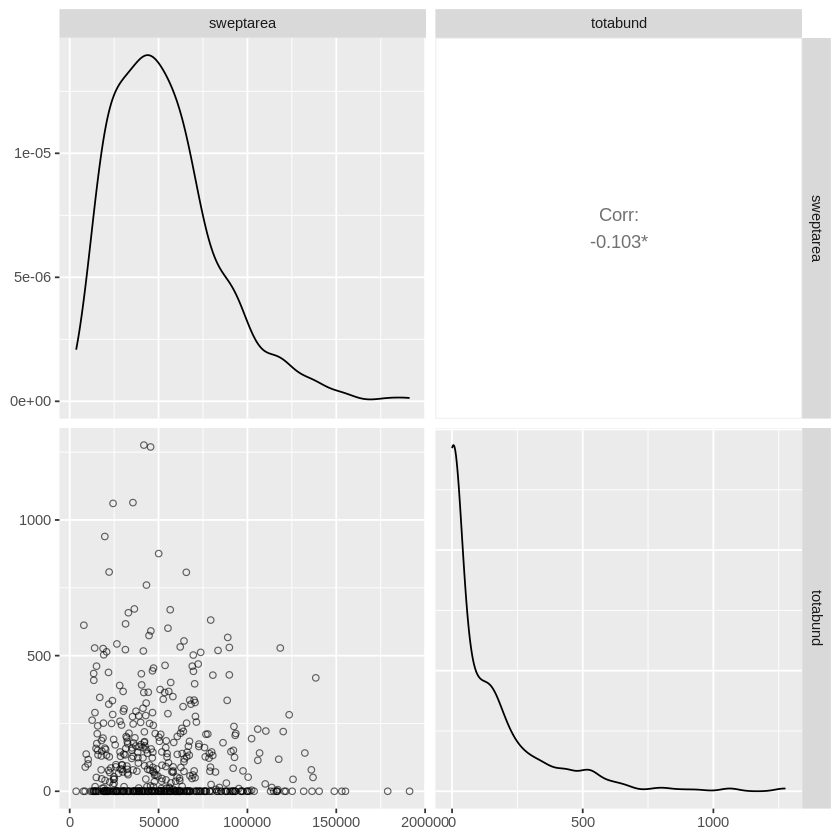

In [162]:
pred_df <- data.frame(sweptarea = as.vector(posterior_samples$x_pred),
                      totabund = as.vector(posterior_samples$y_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 500), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.6, shape = 1)),)

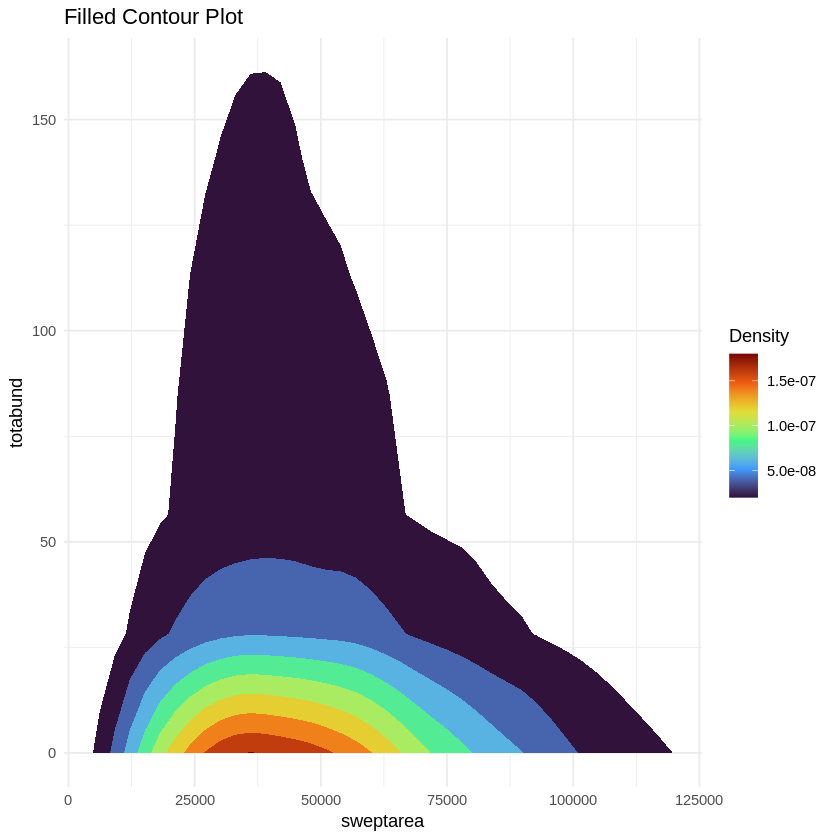

In [163]:
ggplot(pred_df, aes(x = sweptarea, y = totabund)) +
  stat_density_2d(aes(fill = after_stat(level)), geom = "polygon") +
  scale_fill_viridis_c(option = "turbo") +
  theme_minimal() +
  labs(title = "Filled Contour Plot",
       x = "sweptarea", y = "totabund", fill = "Density")

# Doing it With Priors

Bootstrapping priors won't work as well as with the Poisson example, so I will set them based on the parameters found previously, under flat priors. This is not a recommendation, but rather, more of a placeholder to be replaced with more meaningful priors when using this as a template.

In [135]:
x_shape_mean <- mean(posterior_samples$x_shape)
x_shape_sd <- sd(posterior_samples$x_shape)
x_rate_mean <- mean(posterior_samples$x_rate)
x_rate_sd <- sd(posterior_samples$x_rate)
alpha_mean <- mean(posterior_samples$alpha)
alpha_sd <- sd(posterior_samples$alpha)
beta_mean <- mean(posterior_samples$beta)
beta_sd <- sd(posterior_samples$beta)
phi_mean <- mean(posterior_samples$phi)
phi_sd <- sd(posterior_samples$phi)
pi_mean <- mean(posterior_samples$pi)
pi_sd <- sd(posterior_samples$pi)

paste0('x_shape_mean: ', x_shape_mean)
paste0('x_shape_sd: ', x_shape_sd)
paste0('x_rate_mean: ', x_rate_mean)
paste0('x_rate_sd: ', x_rate_sd)
paste0('alpha_mean: ', alpha_mean)
paste0('alpha_sd: ', alpha_sd)
paste0('beta_mean: ', beta_mean)
paste0('beta_sd: ', beta_sd)
paste0('phi_mean: ', phi_mean)
paste0('phi_sd: ', phi_sd)
paste0('pi_mean: ', pi_mean)
paste0('pi_sd: ', pi_sd)

[1] "x_shape_mean: 3.16004107760264"

[1] "x_shape_sd: 0.255565015185233"

[1] "x_rate_mean: 5.79262699186333e-05"

[1] "x_rate_sd: 5.23909849386889e-06"

[1] "alpha_mean: 272.917479891421"

...

[1] "beta_sd: 0.0001644467670538"

[1] "phi_mean: 1.01829587109413"

[1] "phi_sd: 0.108896036462634"

[1] "pi_mean: 0.401088819226326"

[1] "pi_sd: 0.0334900376277043"

In [136]:
stan_code <- "

data {
  int<lower=0> N;
  vector[N] x;
  int<lower=0> y[N];
  real x_shape_mean, x_shape_sd;
  real x_rate_mean, x_rate_sd;
  real alpha_mean, alpha_sd;
  real beta_mean, beta_sd;
  real phi_mean, phi_sd;
  real pi_mean, pi_sd;
}

parameters {
  real<lower=0> x_shape, x_rate;
  real alpha, beta;
  real<lower=0, upper=1>pi;
  real<lower=0> phi;
}

model {
  x_shape ~ normal(x_shape_mean, x_shape_sd);
  x_rate ~ normal(x_rate_mean, x_rate_sd);
  x ~ gamma(x_shape, x_rate);

  alpha ~ normal(alpha_mean, alpha_sd);
  beta ~ normal(beta_mean, beta_sd);
  phi ~ normal(phi_mean, phi_sd);

  pi ~ normal(pi_mean, pi_sd);

  for (n in 1:N) {
    if (y[n] == 0) {
      target += log_mix(pi,
                        0,                                                      // Log prob of y=0 in zero-inflated part
                        neg_binomial_2_lpmf(0 | alpha + beta * x[n], phi));     // Log-prob of y=0 in NB part
    } else {

      target += log1m(pi) + neg_binomial_2_lpmf(y[n] | alpha + beta * x[n], phi);
    }
  }

}

generated quantities {
  vector[N] x_pred;
  int y_pred[N];

  for (n in 1:N) {
    x_pred[n] = gamma_rng(x_shape, x_rate);

    if (bernoulli_rng(pi) == 1) {
      y_pred[n] = 0;
    } else {
      y_pred[n] = neg_binomial_2_rng(fabs(alpha + beta * x_pred[n]), phi);
    }
  }
}
"

We run the model,

In [ ]:
x <- zero_inf_data$sweptarea
y <- zero_inf_data$totabund
N <- length(x)
data_list <- list(N = N, x = x, y = y,
                  x_shape_mean = x_shape_mean,
                  x_shape_sd = x_shape_sd,
                  x_rate_mean = x_rate_mean,
                  x_rate_sd = x_rate_sd,
                  alpha_mean = alpha_mean,
                  alpha_sd = alpha_sd,
                  beta_mean = beta_mean,
                  beta_sd = beta_sd,
                  phi_mean = phi_mean,
                  phi_sd = phi_sd,
                  pi_mean = pi_mean,
                  pi_sd = pi_sd)

model_fit <- stan(model_code = stan_code, data = data_list, warmup=4000,
                 iter = 4200, chains = 2, refresh = 0, cores = 8)

Diagnostics,

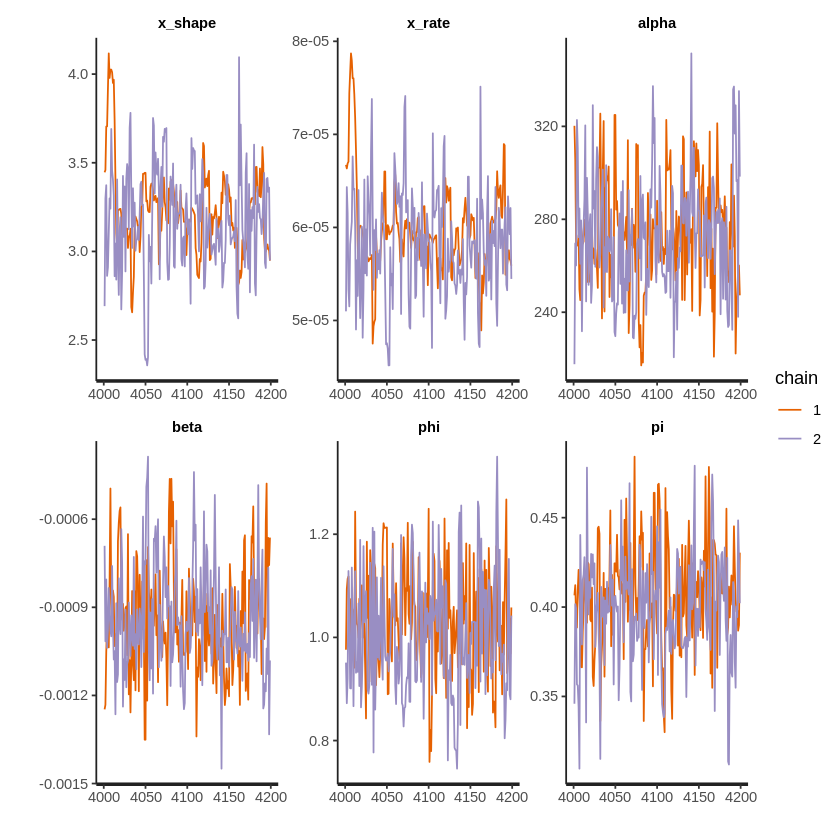

In [147]:
traceplot(model_fit, pars = c('x_shape', 'x_rate', 'alpha', 'beta', 'phi', 'pi'))

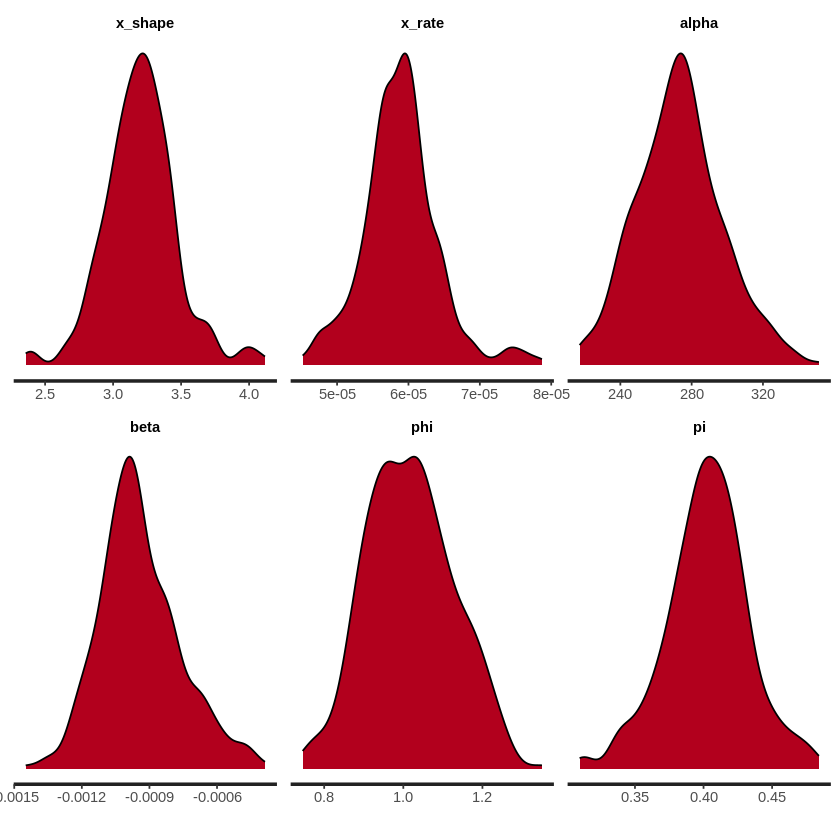

In [148]:
stan_dens(model_fit, pars = c('x_shape', 'x_rate', 'alpha', 'beta', 'phi', 'pi'))

Extract the samples,

In [ ]:
posterior_samples <- extract(model_fit)

And visualize the results.

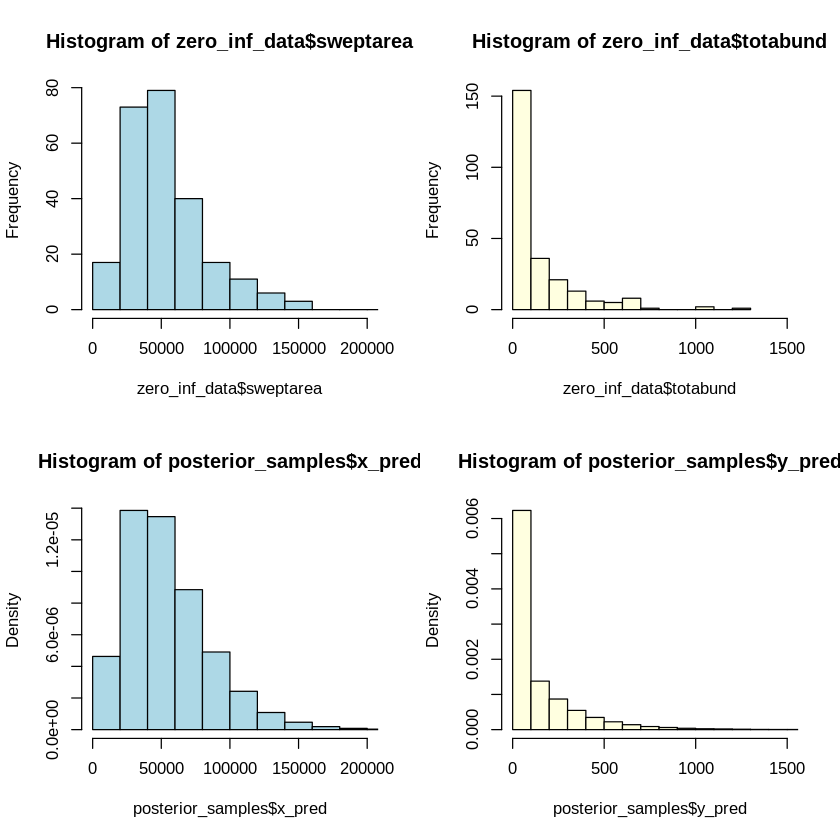

In [152]:
par(mfrow=c(2,2))
hist(zero_inf_data$sweptarea, breaks=10, col="lightblue", xlim = c(0,200000))
hist(zero_inf_data$totabund, breaks=10, col="lightyellow", xlim = c(0,1500))
hist(posterior_samples$x_pred, breaks=12, col="lightblue", probability = TRUE, xlim = c(0,200000))
hist(posterior_samples$y_pred, breaks=20, col="lightyellow", probability = TRUE, xlim = c(0,1500))

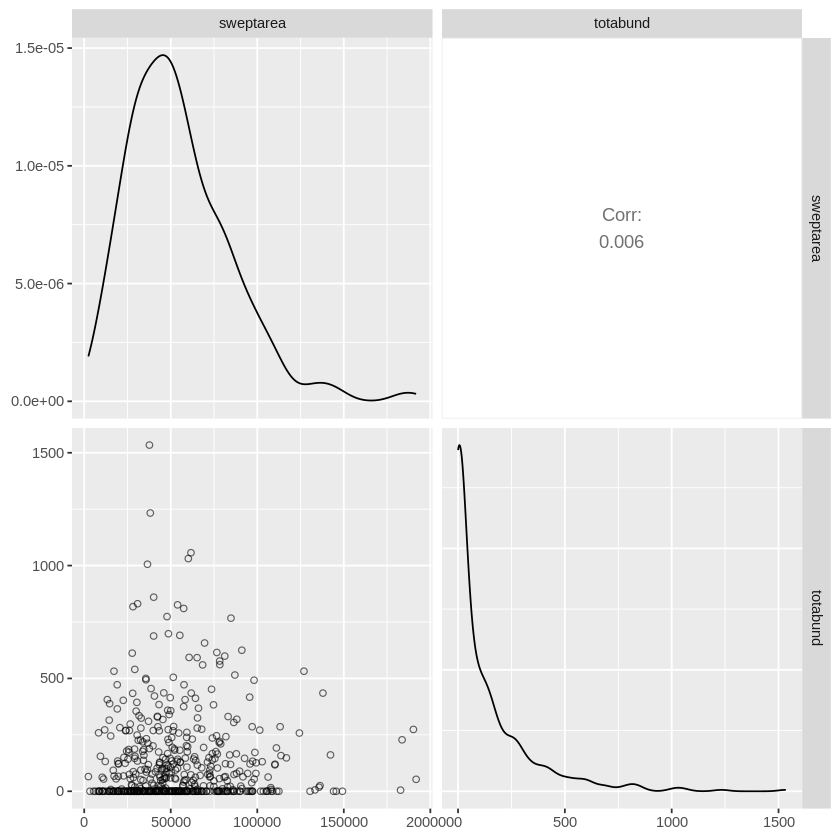

In [153]:
pred_df <- data.frame(sweptarea = as.vector(posterior_samples$x_pred),
                      totabund = as.vector(posterior_samples$y_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 500), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.6, shape = 1)),)

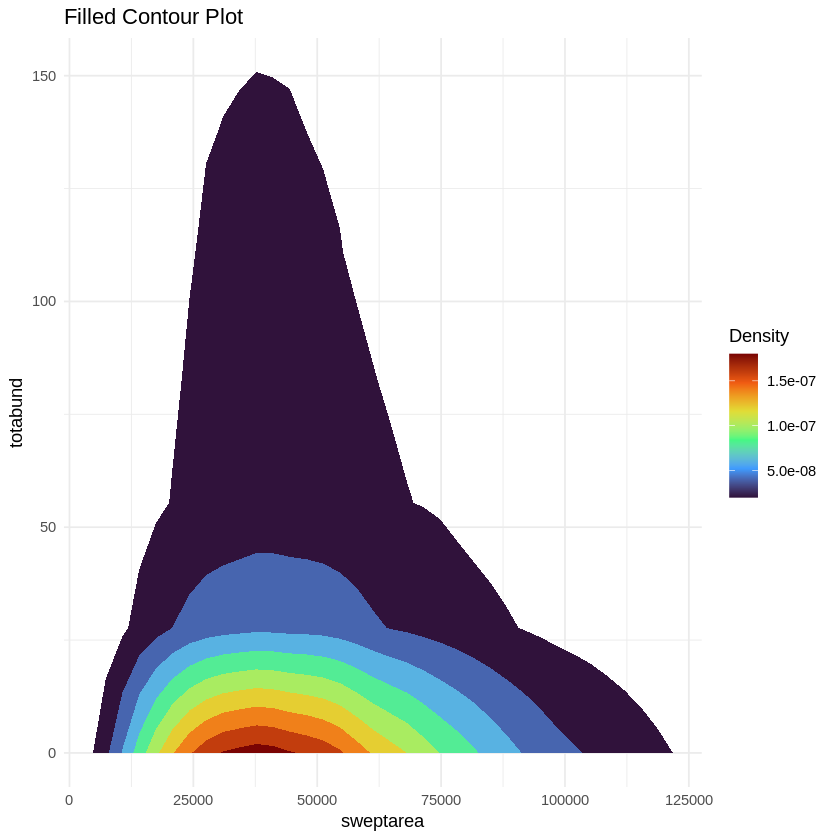

In [154]:
ggplot(pred_df, aes(x = sweptarea, y = totabund)) +
  stat_density_2d(aes(fill = after_stat(level)), geom = "polygon") +
  scale_fill_viridis_c(option = "turbo") +
  theme_minimal() +
  labs(title = "Filled Contour Plot",
       x = "sweptarea", y = "totabund", fill = "Density")

The next article in the series is on gamma-distribution based regression, and can be found <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20III%20-%20Gamma%20Regression.ipynb">here</a>.

# References

- Stan User Guide https://mc-stan.org/docs/stan-users-guide/index.html